In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
from hsflfm.analysis import ResultManager 
from hsflfm.util import load_image_set, load_dictionary 
from PIL import Image 

In [2]:
# swap in where your files are stored, and which frames you want to check 
# this could be automated but I don't know your naming conventions
folder = "C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260526_B"
filename0 = folder + '/20260526_B_0_0_0.tiff'
filename1 = folder + '/20260526_B_1_5_0.tiff' 
filename2 = folder + '/20260526_B_3_5_0.tiff'
filename3 = folder + '/20260526_B_5_5_0.tiff'
filename4 = folder + '/20260526_B_7_5_0.tiff'



filenames = [filename0, filename1, filename2, filename3, filename4]
frames = [0, 10, 20, 30, 40]

# adjust to match your file locations 
results = load_dictionary(folder + '/strike_1_results.json')
calibration_filename = folder + '/calibration_images/calibration_information'

image_sets = [load_image_set(i, calibration_filename) for i in filenames]


In [48]:
# pick any camera number of loop through them 
cam_num = 1
match_points = np.asarray(results["match_points"][cam_num])
flow_cam = np.asarray(results["flow_vectors"])[:, 2 * cam_num:2 * cam_num + 2]

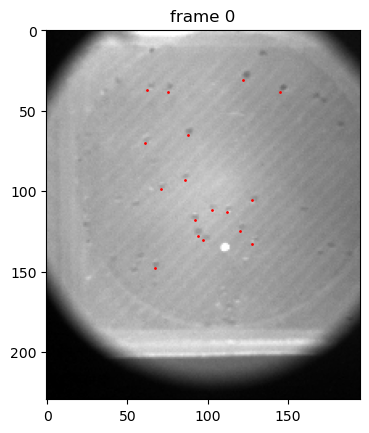

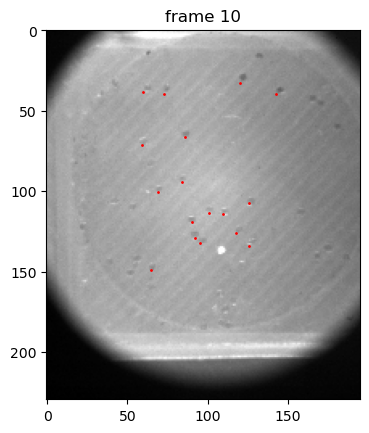

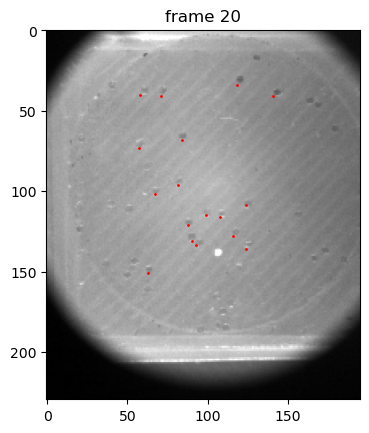

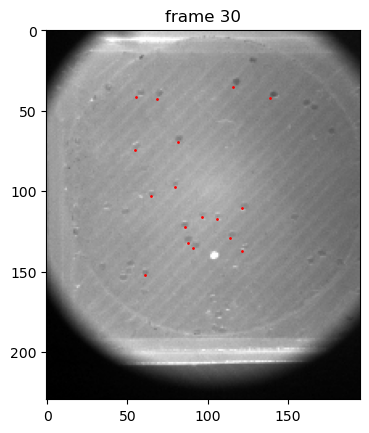

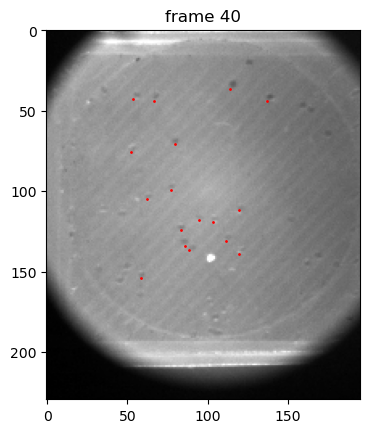

In [49]:
for image_set, frame in zip(image_sets, frames):
    image = image_set[cam_num] 
    locations = match_points[:, :2] + flow_cam[:, :, frame]
    plt.figure()
    plt.imshow(image, cmap='gray')
    plt.scatter(locations[:, 1], locations[:, 0], s=1, c='r')
    plt.title(f"frame {frame}")
    plt.show()

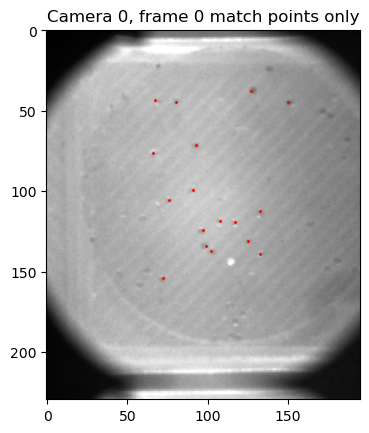

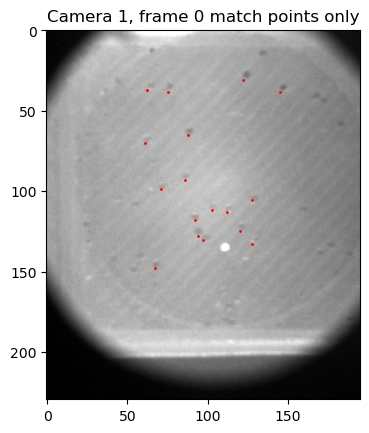

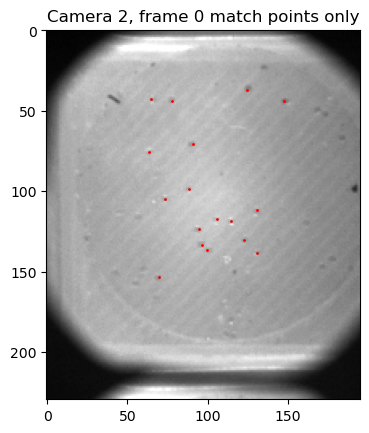

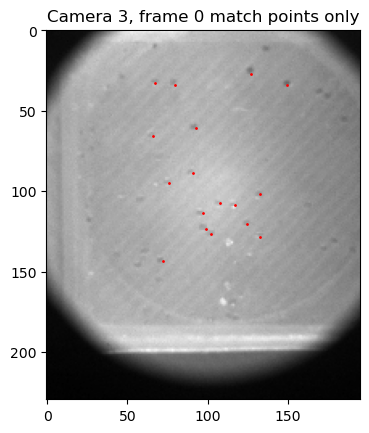

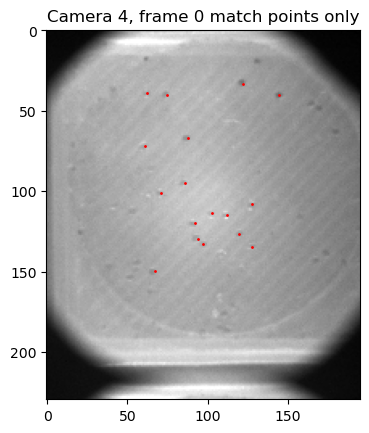

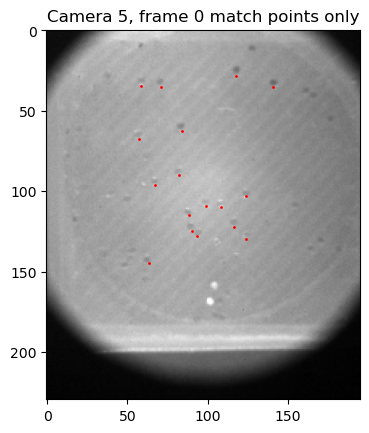

In [34]:
for cam_num in range(6):
    image = image_sets[0][cam_num]
    match_points = np.asarray(results["match_points"][cam_num])
    locations = match_points[:, :2]

    plt.figure()
    plt.imshow(image, cmap="gray")
    plt.scatter(locations[:, 1], locations[:, 0], s=1, c="r")
    plt.title(f"Camera {cam_num}, frame 0 match points only")
    plt.show()

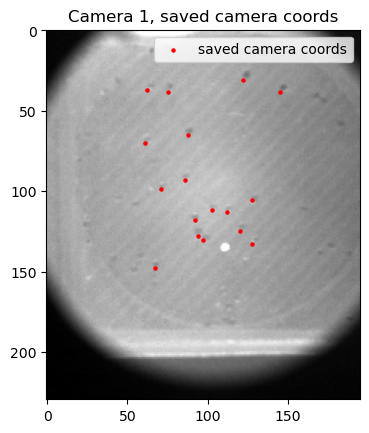

[[6.48898087e+01 8.79065933e+01 3.01504135e-02 7.10000000e+01
  9.10000000e+01]
 [9.27718124e+01 8.59130630e+01 3.01504135e-02 9.90000000e+01
  8.90000000e+01]
 [1.17677803e+02 9.18790436e+01 3.01504135e-02 1.24000000e+02
  9.50000000e+01]
 [1.27644287e+02 9.38661957e+01 3.01504135e-02 1.34000000e+02
  9.70000000e+01]
 [1.30633301e+02 9.68516006e+01 3.01504135e-02 1.37000000e+02
  1.00000000e+02]]


In [39]:
cam_num = 1
pts = np.asarray(results["match_points"][cam_num])
image = image_sets[0][cam_num]

plt.figure()
plt.imshow(image, cmap="gray")

# saved camera-space locations
plt.scatter(pts[:, 1], pts[:, 0], s=5, c="r", label="saved camera coords")

plt.legend()
plt.title(f"Camera {cam_num}, saved camera coords")
plt.show()

print(pts[:5])

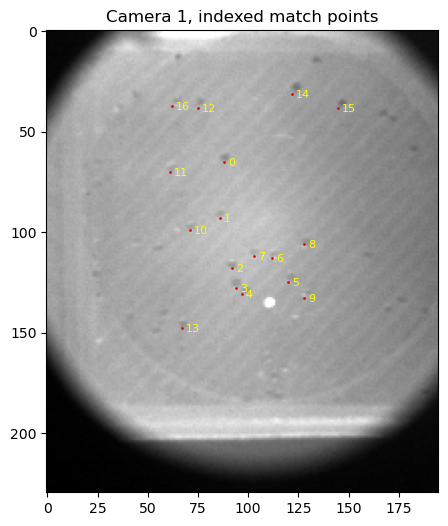

In [44]:
cam_num = 1
pts = np.asarray(results["match_points"][cam_num])
image = image_sets[0][cam_num]

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.scatter(pts[:, 1], pts[:, 0], s=1, c="r")

for i, p in enumerate(pts):
    plt.text(p[1] + 2, p[0] + 2, str(i), color="yellow", fontsize=8)

plt.title(f"Camera {cam_num}, indexed match points")
plt.show()

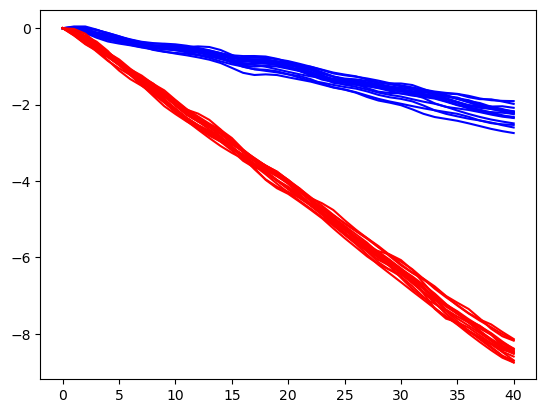

In [18]:
# look at the flow vectors themselves
_ = plt.plot(flow_cam[:, 0].T, label='x flow', color='blue')
_ = plt.plot(flow_cam[:, 1].T, label='y flow', color='red')

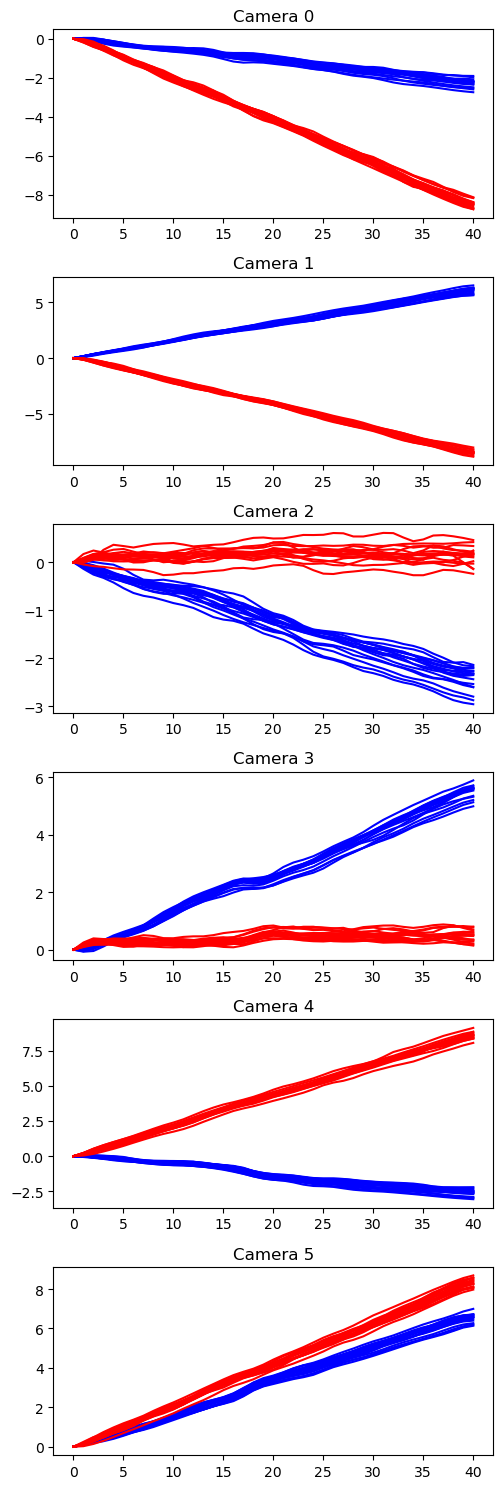

In [46]:
# look at flow vectors for all cameras 
flow_vectors = np.asarray(results["flow_vectors"])
num_cams = flow_vectors.shape[1] // 2 
fig, axes = plt.subplots(num_cams, 1, figsize=(5, 15))
for cam_num in range(num_cams):
    ax = axes[cam_num]
    flow_cam = flow_vectors[:, 2 * cam_num:2 * cam_num + 2]
    _ = ax.plot(flow_cam[:, 0].T, label='x flow', color='blue')
    _ = ax.plot(flow_cam[:, 1].T, label='y flow', color='red')
    ax.set_title(f"Camera {cam_num}")

plt.tight_layout() 